In [29]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import linregress
from visualizations import lineplots_4x4
from processing import filter_region

# load prediction arrays, create array objects

In [2]:
folder_path = 'predictions/8-27-2025/'

In [3]:
folders = [folder for folder in os.listdir(folder_path)]
print('len of folders: ', len(folders))

len of folders:  110


In [4]:
test_sum = np.load(f'{folder_path}image0/sum_arr_image0.npy')
print('test_sum shape: ', test_sum.shape)

test_sum shape:  (1, 100, 7493)


In [5]:
def load_arrs(arr_type: str):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [6]:
sum_arr = load_arrs('sum')
mean_arr = load_arrs('mean')
var_arr = load_arrs('var')
label_arr = load_arrs('label')

In [7]:
print(f'sum shape: {sum_arr.shape}; mean shape: {mean_arr.shape}; var shape: {var_arr.shape}')

sum shape: (110, 100, 7493); mean shape: (110, 7493); var shape: (110, 7493)


In [8]:
np.unique(mean_arr == var_arr, return_counts = True) # ensure we are returning different arrays

(array([False]), array([824230]))

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [9]:
mean_v1 = filter_region(1, label_arr, mean_arr)
var_v1 = filter_region(1, label_arr, var_arr)

In [10]:
print(f'mean shape: {mean_v1.shape}, var shape: {var_v1.shape}')

mean shape: (110, 5312), var shape: (110, 5312)


# get indices to sort

In [ ]:
# run this when wanting to use array with removed values
med_arr = np.nanmedian(mean_v1_removed, axis = 0)
med_arr.shape

NameError: name 'mean_v1_removed' is not defined

In [11]:
# run this when wanting to use array WITHOUT removed values
med_arr = np.nanmedian(mean_v1, axis = 0)
med_arr.shape

(5312,)

In [12]:
for med_num in med_arr: print(med_num)

3.974802479445934
2.3593027226626875
2.7362008299678564
4.895194533690811
4.159150126725436
4.622548931688071
3.8818444656580686
15.556875945329667
9.279563005566597
3.154792268797755
11.045706401318311
11.950191638693212
16.900227708444
7.661633794233203
3.033049823902547
9.30696840506047
6.4384572376310825
6.047185640856624
11.741959682404996
2.748698159493506
5.376979952007532
32.34041048392653
9.889155838564038
4.96723891787231
4.9444513311982154
8.144839701205491
4.180796727389097
5.93926571033895
4.030008012950421
1.8058063982985915
7.819662510082125
2.6598577235639094
7.505931153818965
11.608138296306134
7.710553907603026
6.866133442521095
3.936572218760848
6.677319190055131
11.478807716667653
2.959846276640892
10.883172839507461
2.4146774923428893
8.800222636014222
8.321388820223511
6.008964550942183
3.6290272524207827
9.978706243857742
2.130712605416775
5.477237200438976
5.65389513477683
28.369277135431766
16.382591464966538
8.144303661733865
4.694839561488479
12.6184185665845

In [13]:
sort_indices = np.argsort(med_arr)[::-1]

In [14]:
len(sort_indices)

5312

In [ ]:
# use this for when we remove above x rate
mean_v1_sorted = mean_v1_removed[..., sort_indices]
var_v1_sorted = var_v1_removed[..., sort_indices]

NameError: name 'mean_v1_removed' is not defined

In [15]:
# use this OTHERWISE
mean_v1_sorted = mean_v1[..., sort_indices]
var_v1_sorted = var_v1[..., sort_indices]

# ax**b function in log log space
*scatter plot*

In [17]:
def smooth_func(a, x, b): # used for regression in lineplots_4x4

    return a * (x ** b)

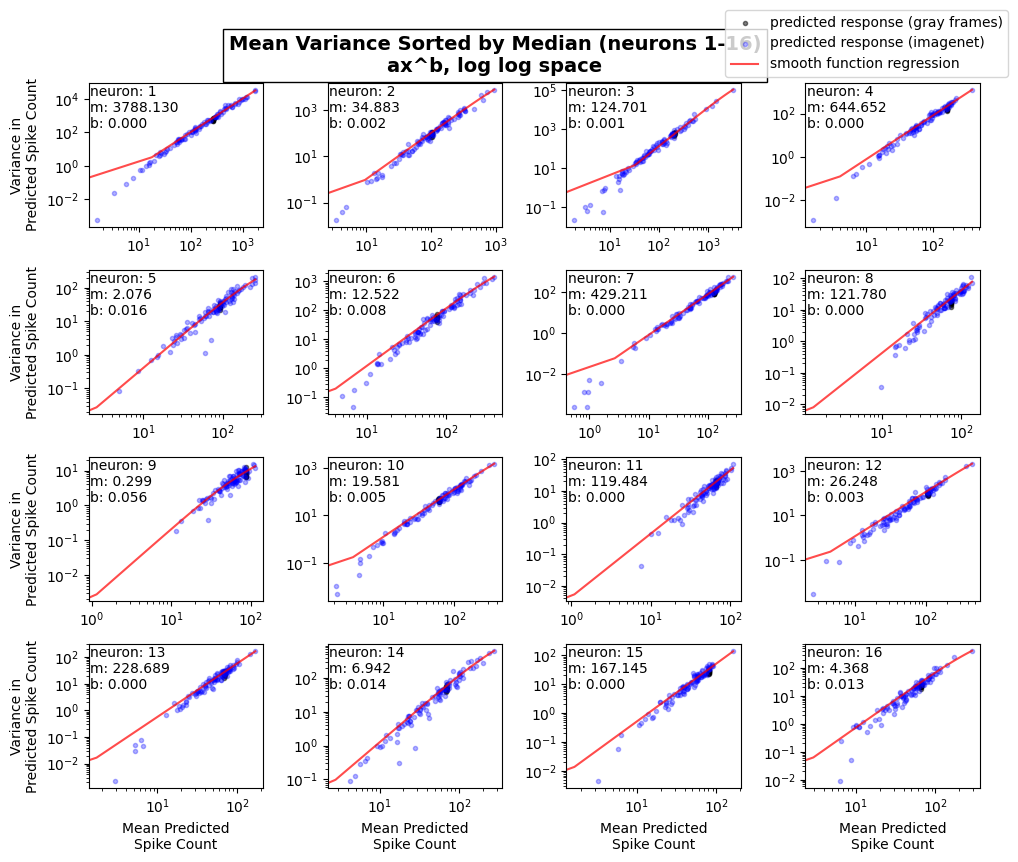

In [20]:
lineplots_4x4("Mean Variance Sorted by Median (neurons 1-16)\nax^b, log log space", mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16)], savefig = False, logspace = True)

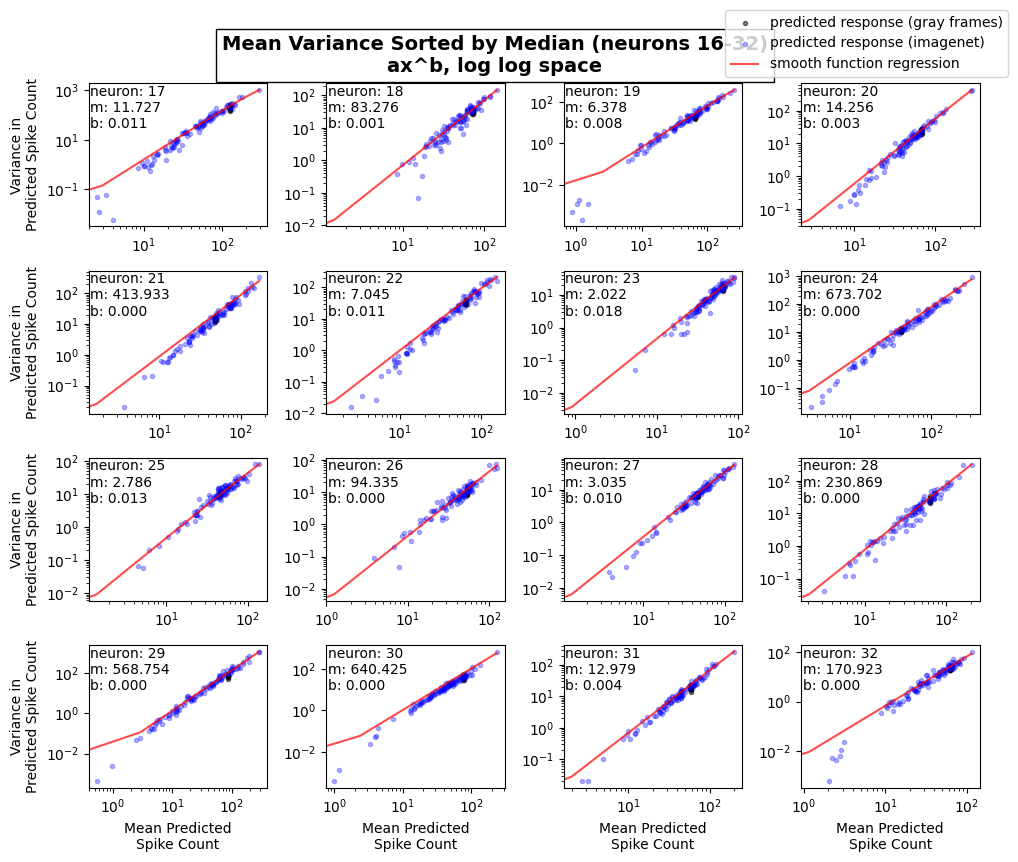

In [28]:
lineplots_4x4("Mean Variance Sorted by Median (neurons 16-32)\nax^b, log log space", mean_v1_sorted, var_v1_sorted, neurons = [i for i in range(16, 32)], savefig = False, logspace = True)

# regression
log(y) = a + blog(x)

In [37]:
mean_masked = mean_v1_sorted
var_masked = var_v1_sorted
main_title = "mean variance regression\nlog log space (neurons 1-16)"

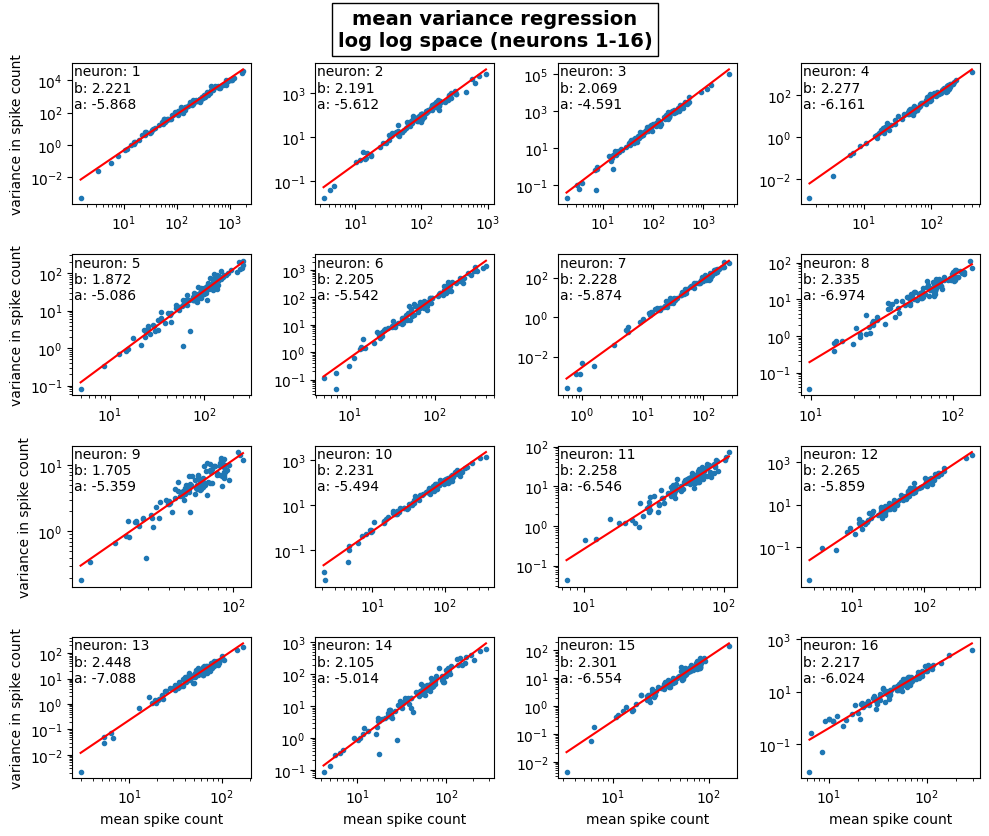

In [38]:
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
neurons = [i for i in range(16)]
for id, neuron in enumerate(neurons):
    i, j = divmod(id, 4)
    ax = axes[i, j]
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy)
    r_squared = r_value**2

    x_fit = np.linspace(x.min(), x.max(), 110) # use 110 since we have 110 images predicted on
    y_fit = np.exp(a) * x_fit**b

    ax.loglog(x, y, '.', label = 'original mean and var points')
    ax.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')

    ax.text(0.01, 0.99, f'neuron: {neuron+1}\nb: {b:.3f}\na: {a:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
        transform = ax.transAxes)

    if i == 3: ax.set_xlabel("mean spike count")
    if j == 0: ax.set_ylabel("variance in spike count")
fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()